# SECCIÓN 1 — PROBLEMA Y DATOS
# Proyecto Final: Predicción de selección al NBA All-Star

**Pregunta: **¿Qué estadísticas de un jugador en temporada regular predicen si será seleccionado al All-Star?**

*   Variable target:	All_star (1 = fue seleccionado, 0 = no)
*   Features clave:	Puntos, asistencias, rebotes, eficiencia, minutos jugados, posición
*   Tipo de modelo:	Clasificación binaria
*   Modelos a comparar:	Regresión Logística vs. XGBoost
*   Métrica principal:	F1-score + AUC-ROC (el dataset será desbalanceado: pocos All-Stars)










In [62]:
# 1.1 Instalación y carga de librerías

!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [41]:
# 1.2 Descargar el dataset desde Kaggle

path = kagglehub.dataset_download("sumitrodatta/nba-aba-baa-stats")
print("Dataset descargado en:", path)

import os
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

Using Colab cache for faster access to the 'nba-aba-baa-stats' dataset.
Dataset descargado en: /kaggle/input/nba-aba-baa-stats
Archivos disponibles: ['Advanced.csv', 'Player Season Info.csv', 'Player Career Info.csv', 'Player Shooting.csv', 'Opponent Stats Per Game.csv', 'Draft Pick History.csv', 'Player Totals.csv', 'Opponent Stats Per 100 Poss.csv', 'Per 100 Poss.csv', 'Team Summaries.csv', 'Player Per Game.csv', 'All-Star Selections.csv', 'End of Season Teams (Voting).csv', 'Player Play By Play.csv', 'End of Season Teams.csv', 'Team Stats Per 100 Poss.csv', 'Per 36 Minutes.csv', 'Opponent Totals.csv', 'Team Abbrev.csv', 'Player Award Shares.csv', 'Team Totals.csv', 'Team Stats Per Game.csv']


In [42]:
# 1.3 Carga y selección del archivo principal. Se usa el archivo de estadísticas por temporada (Player Per Game)

df_raw = pd.read_csv(f"{path}/Player Per Game.csv")

print(f"Dimensiones del dataset: {df_raw.shape}")
print(f"\nColumnas disponibles ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())

Dimensiones del dataset: (33339, 32)

Columnas disponibles (32):
['season', 'lg', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game']


In [43]:
# 1.4 Exploración inicial
df_raw.head(10)

,season,lg,player,player_id,age,team,pos,g,gs,mp_per_game,...,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,73,57.0,23.9,...,0.554,2.4,4.3,6.7,1.4,0.9,0.7,0.9,1.7,10.1
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,22.8,...,0.580,4.5,4.1,8.6,1.5,0.7,0.6,1.1,1.7,5.8
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,73,73.0,32.4,...,0.778,2.0,8.0,10.0,3.2,1.2,0.7,1.6,1.7,20.1
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,2TM,SG,62,13.0,15.7,...,0.837,0.7,1.5,2.3,0.8,0.4,0.3,0.5,1.5,5.1
4,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,42,13.0,15.5,...,0.862,0.8,1.5,2.3,0.7,0.4,0.3,0.5,1.8,4.3
5,2026,NBA,Ochai Agbaji,agbajoc01,25.0,BRK,SG,20,0.0,16.2,...,0.786,0.7,1.7,2.3,0.9,0.4,0.3,0.6,0.9,6.7
6,2026,NBA,Santi Aldama,aldamsa01,25.0,MEM,PF,43,11.0,27.9,...,0.667,1.6,5.1,6.7,2.9,0.9,0.7,1.3,1.6,14.0
7,2026,NBA,Nickeil Alexander-Walker,alexani01,27.0,ATL,SG,78,71.0,33.4,...,0.902,0.7,2.8,3.4,3.7,1.3,0.5,2.1,2.2,20.8
8,2026,NBA,Trey Alexander,alexatr01,22.0,NOP,SG,9,0.0,12.3,...,0.600,0.1,1.1,1.2,1.0,0.7,0.2,0.3,1.4,5.2
9,2026,NBA,Grayson Allen,allengr01,30.0,PHO,SG,51,27.0,28.8,...,0.857,0.7,2.3,3.0,3.8,1.4,0.3,1.6,2.3,16.5


In [44]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33339 entries, 0 to 33338
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   season         33339 non-null  int64  
 1   lg             33339 non-null  object 
 2   player         33339 non-null  object 
 3   player_id      33339 non-null  object 
 4   age            33319 non-null  float64
 5   team           33339 non-null  object 
 6   pos            32142 non-null  object 
 7   g              33339 non-null  int64  
 8   gs             25161 non-null  float64
 9   mp_per_game    32256 non-null  float64
 10  fg_per_game    33339 non-null  float64
 11  fga_per_game   33339 non-null  float64
 12  fg_percent     33175 non-null  float64
 13  x3p_per_game   26987 non-null  float64
 14  x3pa_per_game  26986 non-null  float64
 15  x3p_percent    22714 non-null  float64
 16  x2p_per_game   26987 non-null  float64
 17  x2pa_per_game  26987 non-null  float64
 18  x2p_pe

In [45]:
df_raw.describe().round(2)

,season,age,g,gs,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,...,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
count,33339.00,33319.00,33339.00,25161.00,32256.00,33339.00,33339.00,33175.00,26987.00,26986.00,...,31974.00,28693.00,28693.00,32445.00,33339.00,27737.00,27739.00,27703.00,33338.00,33339.00
mean,1996.39,26.47,48.45,22.49,20.13,3.17,7.14,0.43,0.49,1.43,...,0.72,1.04,2.53,3.72,1.88,0.66,0.40,1.25,1.98,8.35
std,20.93,3.86,26.60,27.92,10.20,2.30,4.82,0.10,0.68,1.80,...,0.14,0.89,1.85,2.80,1.78,0.48,0.49,0.85,0.92,6.11
min,1947.00,18.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1980.00,24.00,24.00,0.00,11.70,1.40,3.40,0.39,0.00,0.00,...,0.66,0.40,1.20,1.70,0.60,0.30,0.10,0.60,1.30,3.60
50%,1999.00,26.00,53.00,7.00,19.40,2.60,6.00,0.44,0.20,0.60,...,0.75,0.80,2.10,3.00,1.30,0.60,0.30,1.10,2.00,6.90
75%,2014.00,29.00,73.00,42.00,28.50,4.50,10.00,0.48,0.80,2.30,...,0.81,1.40,3.40,4.90,2.50,0.90,0.50,1.70,2.60,11.70
max,2026.00,46.00,90.00,84.00,48.50,20.00,39.50,1.00,5.30,13.20,...,1.00,7.20,13.70,27.20,14.50,4.10,6.00,5.70,6.00,50.40


In [46]:
# 1.5 Construcción de la variable target: all_star

df_allstar = pd.read_csv(f"{path}/All-Star Selections.csv")
print(df_allstar.shape)
df_allstar.head()

(2058, 6)


,player,player_id,team,season,lg,replaced
0,Scottie Barnes,barnesc01,Team Stars,2026,NBA,False
1,Devin Booker,bookede01,Team Stars,2026,NBA,False
2,Cade Cunningham,cunnica01,Team Stars,2026,NBA,False
3,Jalen Duren,durenja01,Team Stars,2026,NBA,False
4,Anthony Edwards,edwaran01,Team Stars,2026,NBA,False


In [47]:
# Se crea un set de pares (jugador, temporada) que fueron All-Star

allstar_set = set(zip(df_allstar['player'], df_allstar['season']))

# Se añade la columna target al dataset principal
df_raw['all_star'] = df_raw.apply(
    lambda row: 1 if (row['player'], row['season']) in allstar_set else 0,
    axis=1
)

print("Distribución de la variable target:")
print(df_raw['all_star'].value_counts())
print(f"\nPorcentaje All-Stars: {df_raw['all_star'].mean()*100:.2f}%")

Distribución de la variable target:
all_star
0    31183
1     2156
Name: count, dtype: int64

Porcentaje All-Stars: 6.47%


In [48]:
# 1.6 Filtrado: solo NBA, solo temporadas modernas (1980+)

df = df_raw[
    (df_raw['lg'] == 'NBA') &
    (df_raw['season'] >= 1980)
].copy()

print(f"Filas tras filtrar: {df.shape[0]}")

Filas tras filtrar: 25349


In [49]:
# 1.7 Limpieza de datos

# Duplicados
print(f"Duplicados: {df.duplicated().sum()}")
df = df.drop_duplicates()

# Jugadores con múltiples equipos en la misma temporada → quedarse con TOT (total). Se ordena para que 'TOT' quede primero al ordenar alfabéticamente descendente
df = df.sort_values('team', ascending=False).drop_duplicates(subset=['player', 'season'], keep='first')
print(f"Filas tras deduplicar por jugador/temporada: {df.shape[0]}")

# Valores nulos
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(f"\nColumnas con nulos:\n{nulos}")

# Imputar nulos numéricos con 0 (ausencia de estadística, ej: 3P% si no tiró triples)
cols_numericas = df.select_dtypes(include='number').columns
df[cols_numericas] = df[cols_numericas].fillna(0)

print(f"\nNulos restantes: {df.isnull().sum().sum()}")

Duplicados: 0
Filas tras deduplicar por jugador/temporada: 20526

Columnas con nulos:
x3p_percent     3044
ft_percent       857
gs               480
x2p_percent      172
fg_percent       100
e_fg_percent     100
pos                1
dtype: int64

Nulos restantes: 1


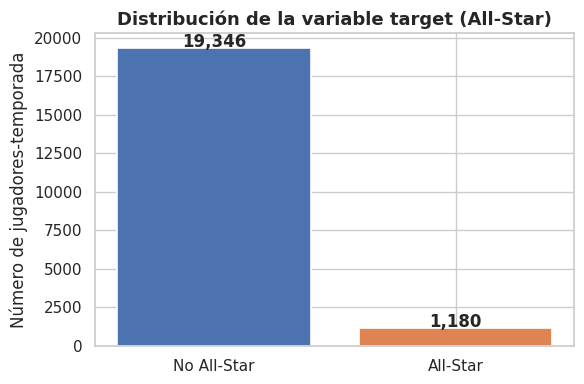


El dataset está muy desbalanceado (~5% All-Stars).
Esto motiva el uso de F1-score y AUC-ROC como métricas principales,
en lugar de accuracy simple, lo cual no sería bueno para esto



In [50]:
# 1.8 Visualizaciones exploratorias

# --- Visualización 1: Desbalance de clases ---

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['all_star'].value_counts()
bars = ax.bar(['No All-Star', 'All-Star'], counts.values,
               color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Distribución de la variable target (All-Star)', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de jugadores-temporada')
plt.tight_layout()
plt.savefig('viz1_desbalance_clases.png', dpi=150)
plt.show()

print("""
El dataset está muy desbalanceado (~5% All-Stars).
Esto motiva el uso de F1-score y AUC-ROC como métricas principales,
en lugar de accuracy simple, lo cual no sería bueno para esto
""")

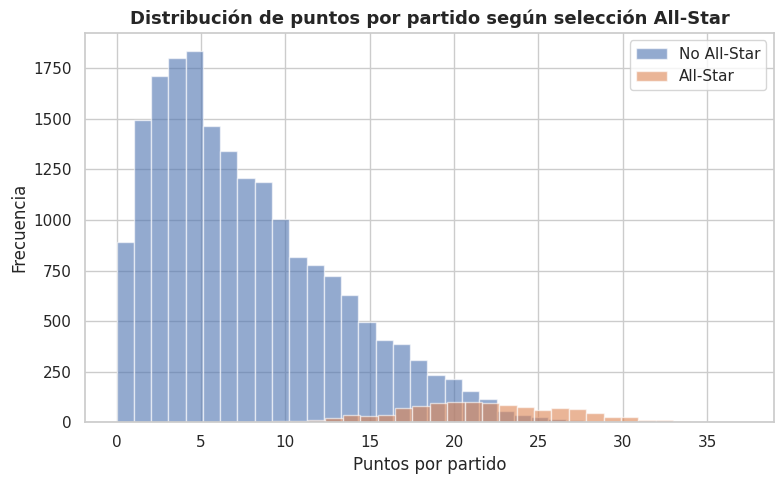


Los jugadores All-Star concentran su distribución en rangos altos de puntos (>18 ppg), 
mientras que los no seleccionados se agrupan en valores bajos, lo que confirma que esta variable
será relevante para el modelo.



In [51]:
# --- Visualización 2: Distribución de puntos por grupo ---

fig, ax = plt.subplots(figsize=(8, 5))
for label, color, nombre in [(0, '#4C72B0', 'No All-Star'), (1, '#DD8452', 'All-Star')]:
    subset = df[df['all_star'] == label]['pts_per_game']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=nombre, edgecolor='white')
ax.set_title('Distribución de puntos por partido según selección All-Star', fontsize=13, fontweight='bold')
ax.set_xlabel('Puntos por partido')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('viz2_puntos_allstar.png', dpi=150)
plt.show()

print("""
Los jugadores All-Star concentran su distribución en rangos altos de puntos (>18 ppg),
mientras que los no seleccionados se agrupan en valores bajos, lo que confirma que esta variable
será relevante para el modelo.
""")

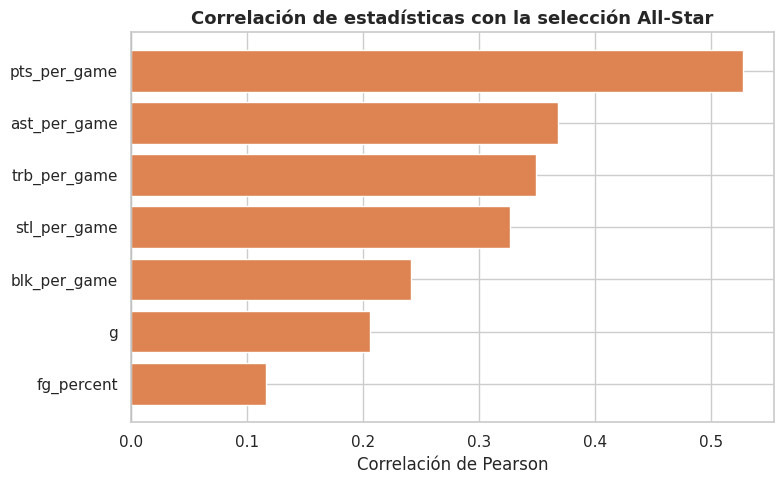


Los puntos por partido (pts_per_game) muestran la correlación más alta con ser seleccionado All-Star, 
seguidos de asistencias y rebotes. Esto guiará la ingeniería de features en la siguiente sección.



In [52]:
# --- Visualización 3: Correlación de features principales con all_star ---

features_viz = ['pts_per_game', 'ast_per_game', 'trb_per_game',
                 'stl_per_game', 'blk_per_game', 'fg_percent', 'g']

correlaciones = df[features_viz + ['all_star']].corr()['all_star'].drop('all_star').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Correlación de estadísticas con la selección All-Star', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.savefig('viz3_correlaciones.png', dpi=150)
plt.show()

print("""
Los puntos por partido (pts_per_game) muestran la correlación más alta con ser seleccionado All-Star,
seguidos de asistencias y rebotes. Esto guiará la ingeniería de features en la siguiente sección.
""")

In [53]:
# 1.9 Dataset final listo para modelado

print("=== RESUMEN SECCIÓN 1 ===")
print(f"Filas finales:       {df.shape[0]:,}")
print(f"Columnas:            {df.shape[1]}")
print(f"All-Stars:           {df['all_star'].sum():,}  ({df['all_star'].mean()*100:.1f}%)")
print(f"Temporadas:          {df['season'].min()} – {df['season'].max()}")
print(f"Jugadores únicos:    {df['player'].nunique():,}")
print(f"Nulos restantes:     {df.isnull().sum().sum()}")

=== RESUMEN SECCIÓN 1 ===
Filas finales:       20,526
Columnas:            33
All-Stars:           1,180  (5.7%)
Temporadas:          1980 – 2026
Jugadores únicos:    3,796
Nulos restantes:     1


# SECCIÓN 2 — MODELADO
# Regresión Logística vs. XGBoost con Pipeline de Scikit-learn


In [54]:
# 2.1 Instalación y librerías

!pip install xgboost shap -q

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay, f1_score)
from xgboost import XGBClassifier
import shap

In [55]:
# 2.2 Selección de features y variable target

FEATURES = [
    'age', 'g', 'gs', 'mp_per_game',
    'pts_per_game', 'ast_per_game', 'trb_per_game',
    'stl_per_game', 'blk_per_game', 'tov_per_game',
    'fg_percent', 'ft_percent', 'x3p_percent',
    'orb_per_game', 'drb_per_game', 'pf_per_game',
    'fg_per_game', 'fga_per_game', 'ft_per_game', 'fta_per_game'
]

TARGET = 'all_star'

X = df[FEATURES]
y = df[TARGET]

print(f"Features: {len(FEATURES)}")
print(f"Positivos (All-Star): {y.sum()}  ({y.mean()*100:.1f}%)")
print(f"Negativos:            {(y==0).sum()}")

Features: 20
Positivos (All-Star): 1180  (5.7%)
Negativos:            19346


In [56]:
# 2.3 División train / test (estratificada)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # mantiene proporción de All-Stars en ambos sets
)

print(f"Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas")
print(f"All-Stars en train: {y_train.sum()}  |  en test: {y_test.sum()}")

Train: 16,420 filas  |  Test: 4,106 filas
All-Stars en train: 944  |  en test: 236


In [57]:
# 2.4 Pipeline — Modelo 1: REGRESIÓN LOGÍSTICA

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',   # corrige desbalance
        max_iter=1000,
        random_state=42
    ))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr, target_names=['No All-Star', 'All-Star']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

 No All-Star       1.00      0.92      0.96      3870
    All-Star       0.41      0.97      0.58       236

    accuracy                           0.92      4106
   macro avg       0.71      0.95      0.77      4106
weighted avg       0.96      0.92      0.93      4106

AUC-ROC: 0.9835


In [58]:
# 2.5 Pipeline — Modelo 2: XGBoost

# Se calcula scale_pos_weight para manejar desbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.2f}")

pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        scale_pos_weight=scale,    # corrige desbalance
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ))
])

pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)
y_prob_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No All-Star', 'All-Star']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

scale_pos_weight: 16.39

=== XGBoost ===
              precision    recall  f1-score   support

 No All-Star       1.00      0.94      0.97      3870
    All-Star       0.51      0.93      0.65       236

    accuracy                           0.94      4106
   macro avg       0.75      0.94      0.81      4106
weighted avg       0.97      0.94      0.95      4106

AUC-ROC: 0.9842


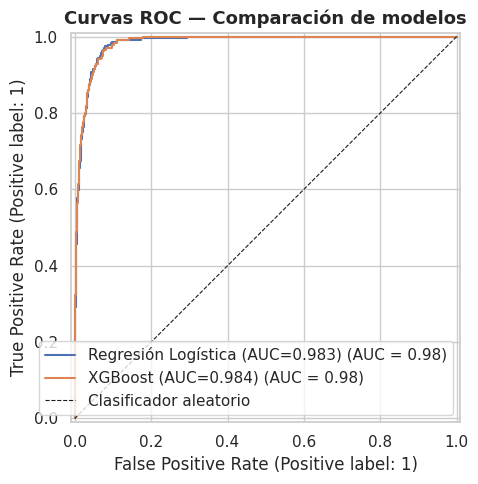


Un AUC cercano a 1.0 indica que el modelo distingue bien entre All-Stars y no All-Stars. 
Se compara ambos modelos sobre el mismo test set estratificado para una evaluación adecuada.



In [59]:
# 2.6 Comparación de modelos — Visualización 4: Curvas ROC

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_lr,
    name=f"Regresión Logística (AUC={roc_auc_score(y_test, y_prob_lr):.3f})",
    color='#4C72B0', ax=ax)

RocCurveDisplay.from_predictions(y_test, y_prob_xgb,
    name=f"XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})",
    color='#DD8452', ax=ax)

ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Clasificador aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('viz4_curvas_roc.png', dpi=150)
plt.show()

print("""
Un AUC cercano a 1.0 indica que el modelo distingue bien entre All-Stars y no All-Stars.
Se compara ambos modelos sobre el mismo test set estratificado para una evaluación adecuada.
""")

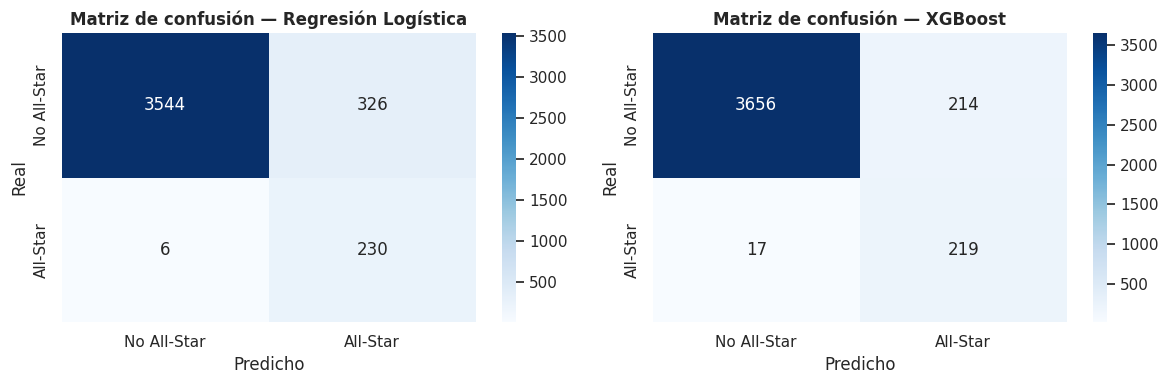


La matriz muestra cuántos All-Stars reales fueron correctamente identificados (verdaderos positivos) 
y cuántos se perdieron (falsos negativos). En datasets desbalanceados, minimizar los falsos negativos es prioritario.



In [60]:
# 2.7 Comparación de modelos — Visualización 5: Matrices de confusión

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_lr, y_pred_xgb],
    ['Regresión Logística', 'XGBoost']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No All-Star', 'All-Star'],
                yticklabels=['No All-Star', 'All-Star'])
    ax.set_title(f'Matriz de confusión — {titulo}', fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('viz5_matrices_confusion.png', dpi=150)
plt.show()

print("""
La matriz muestra cuántos All-Stars reales fueron correctamente identificados (verdaderos positivos)
y cuántos se perdieron (falsos negativos). En datasets desbalanceados, minimizar los falsos negativos es prioritario.
""")

In [61]:
# 2.8 Tabla resumen de métricas

resumen = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'XGBoost'],
    'F1 (All-Star)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}).round(4)

print(resumen.to_string(index=False))
print("\n Mejor modelo:", resumen.loc[resumen['AUC-ROC'].idxmax(), 'Modelo'])

             Modelo  F1 (All-Star)  AUC-ROC
Regresión Logística         0.5808   0.9835
            XGBoost         0.6547   0.9842

 Mejor modelo: XGBoost
